# 06 — Ngưỡng quyết định và chi phí

**Mục tiêu.** Mô hình của giai đoạn 4 (`xgboost` + `class_weight`, cấu hình mặc định) trả về một
**xác suất**. Biến xác suất đó thành quyết định chặn / cho qua là một lựa chọn riêng, và là lựa
chọn quyết định trực tiếp số tiền mất và khối lượng việc của đội thẩm định. Notebook này chọn
ngưỡng theo chi phí nghiệp vụ thay vì mặc định 0,5, rồi hỏi: kết luận có đứng vững khi giả định
chi phí sai không?

**Việc tương ứng:** T-29 … T-31 trong [TASKS.md](../TASKS.md).

| Việc | Nội dung | Điều kiện xong |
|---|---|---|
| T-29 | đường cong chi phí + 4 phương án ngưỡng, chọn trên **out-of-fold** | ML-08 được tôn trọng |
| T-30 | bảng 4 ngưỡng × (cảnh báo/ngày, TP, FP, FN, Precision, Recall, chi phí) | kèm đoạn diễn giải "hạ ngưỡng … bắt thêm N vụ, đổi lại M cảnh báo giả, tiết kiệm ròng X" |
| T-31 | độ nhạy theo tỷ lệ chi phí 5:1 → 100:1 | hình cho thấy ngưỡng tối ưu dịch chuyển thế nào (AC-M8) |

**Quy tắc ML-08.** Mọi ngưỡng được **chọn** trên điểm out-of-fold của tập huấn luyện. Tập kiểm thử
chỉ được **đo** tại các ngưỡng đã chốt. `tests/test_no_leakage.py` quét notebook này và đỏ ngay nếu
`pick_threshold`, `threshold_alternatives` hay `sensitivity_analysis` được gọi trên nhãn test.

**Sản phẩm bàn giao.** `reports/threshold_comparison.csv`, `reports/cost_sensitivity.csv` và các
hình `06_*`. Mục 6 (bổ sung sau rà soát): `reports/amount_cost_comparison.csv`,
`reports/amount_cost_bootstrap.csv`, `reports/block_threshold.csv`, `reports/calibration.csv`.

**Đơn vị tiền.** Bộ dữ liệu không ghi đơn vị của `Amount`; giao dịch của chủ thẻ châu Âu nên
dự án quy ước **EUR** (02 §3) — cùng đơn vị với API và giao diện.

In [1]:
import json
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score

from src import plots
from src.config import DATASET_DAYS, DEFAULT_COST_FN, DEFAULT_COST_FP, FIGURES_DIR, RANDOM_STATE, REPORTS_DIR
from src.data import load_prepared, split_data
from src.evaluate import baseline_pr_auc, bootstrap_ci, bootstrap_threshold_diff
from src.features import build_features
from src.modeling import build_pipeline, make_cv, oof_scores
from src.threshold import (
    NAIVE_THRESHOLD,
    compare_thresholds,
    cost_curve,
    metrics_at_threshold,
    sensitivity_analysis,
    threshold_alternatives,
)

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

# ---- Cấu hình -------------------------------------------------------------
DUONG_DAN_OOF = REPORTS_DIR / "grid_results.npz"
N_BOOT = 1000
TY_LE_MAC_DINH = DEFAULT_COST_FN / DEFAULT_COST_FP      # 122,21 / 5 ≈ 24,4 : 1
RECALL_TOI_THIEU = 0.90                                   # 04 §6.3
NGAN_SACH_CANH_BAO = 200.0                                # cảnh báo mỗi ngày, 04 §6.3

# Tên hiển thị của 4 phương án bắt buộc (04 §6.4) + max_f1 để tham khảo
TEN_PHUONG_AN = {
    "default_naive": "0,5 (mặc định)",
    "min_expected_cost": "τ* tối ưu chi phí",
    f"recall_at_least_{int(RECALL_TOI_THIEU * 100)}": "τ cho recall ≥ 90%",
    f"budget_{int(NGAN_SACH_CANH_BAO)}_alerts": "τ cho 200 cảnh báo/ngày",
    "max_f1": "τ cực đại F1 (tham khảo)",
}
MAU = {"0,5 (mặc định)": "#7F7F7F", "τ* tối ưu chi phí": "#E45756", "τ cho recall ≥ 90%": "#F58518",
       "τ cho 200 cảnh báo/ngày": "#4C78A8", "τ cực đại F1 (tham khảo)": "#54A24B"}
print(f"Tỷ lệ chi phí mặc định FN:FP = {TY_LE_MAC_DINH:.2f} : 1")

Tỷ lệ chi phí mặc định FN:FP = 24.44 : 1


---
## 1. Dữ liệu, điểm out-of-fold và điểm tập kiểm thử

Cách chia lặp lại đúng notebook 03–05 (`random_state=42`, 95 gian lận trong tập test).

- **Điểm out-of-fold** của `xgboost + class_weight` đã được tính ở giai đoạn 3 và lưu trong
  `reports/grid_results.npz` — cùng `StratifiedKFold(5, random_state=42)`, cùng cấu hình mặc định
  mà giai đoạn 4 đã chốt. Thiếu tệp thì ô dưới tự tính lại (khoảng 1–2 phút).
- **Điểm tập kiểm thử** đến từ mô hình huấn luyện lại trên toàn bộ tập huấn luyện.

In [2]:
df, _ = load_prepared()

X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train = build_features(X_train_tho)
X_test = build_features(X_test_tho)
y_train, y_test = y_train.to_numpy(), y_test.to_numpy()

PHAN_TRAIN = len(y_train) / len(df)
PHAN_TEST = len(y_test) / len(df)
assert int(y_test.sum()) == 95, "tập kiểm thử phải trùng với notebook 03 (95 gian lận)"

if DUONG_DAN_OOF.exists():
    with np.load(DUONG_DAN_OOF) as npz:
        oof = npz["xgboost__class_weight"]
    nguon_oof = f"đọc lại {DUONG_DAN_OOF.relative_to(ROOT)}"
else:
    oof = oof_scores(build_pipeline("xgboost", "class_weight", y=y_train), X_train, y_train,
                     cv=make_cv(random_state=RANDOM_STATE))
    nguon_oof = "tính lại bằng oof_scores()"
assert oof.shape == y_train.shape

bat_dau = time.perf_counter()
mo_hinh = build_pipeline("xgboost", "class_weight", y=y_train).fit(X_train, y_train)
diem_test = mo_hinh.predict_proba(X_test)[:, 1]

print(f"\nĐiểm out-of-fold ({nguon_oof}): PR-AUC {average_precision_score(y_train, oof):.4f}, "
      f"{np.unique(oof).size:,} giá trị khác nhau")
print(f"Tập kiểm thử: huấn luyện lại {time.perf_counter() - bat_dau:.0f}s, PR-AUC "
      f"{average_precision_score(y_test, diem_test):.4f} (đường cơ sở {baseline_pr_auc(y_test):.5f})")
print(f"Phần dữ liệu: train {PHAN_TRAIN:.4f}, test {PHAN_TEST:.4f} — dùng để quy đổi ra cảnh báo/ngày")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.



Điểm out-of-fold (đọc lại reports\grid_results.npz): PR-AUC 0.8532, 221,674 giá trị khác nhau
Tập kiểm thử: huấn luyện lại 12s, PR-AUC 0.8252 (đường cơ sở 0.00167)
Phần dữ liệu: train 0.8000, test 0.2000 — dùng để quy đổi ra cảnh báo/ngày


---
## 2. Đường cong chi phí và bốn phương án ngưỡng — T-29

```
Chi phí(τ) = cost_fn × FN(τ) + cost_fp × FP(τ),   cost_fn = 122,21   cost_fp = 5,00
```

Bốn tiêu chí ở [04 §6.3](../docs/04-thiet-ke-mo-hinh-ml.md), cộng `max_f1` để tham khảo:

| Phương án | Chọn τ thế nào (trên out-of-fold) |
|---|---|
| τ\* tối ưu chi phí | cực tiểu hàm chi phí |
| τ cho recall ≥ 90% | τ **lớn nhất** còn giữ recall ≥ 0,90 |
| τ cho 200 cảnh báo/ngày | τ **nhỏ nhất** mà số cảnh báo/ngày ≤ 200 |
| 0,5 | mặc định, làm mốc |

**Ngưỡng ứng viên: mọi điểm out-of-fold khác nhau, không phải lưới 200 điểm.** `threshold_grid()`
mặc định (200 lượng tử) đủ cho API, nhưng quá thô ở phần đuôi — nơi mọi cảnh báo phát sinh. Ô dưới
so hai cách để thấy vì sao báo cáo phải dùng nghiệm chính xác. Nhờ `searchsorted`, quét cả
222.000 ngưỡng vẫn chỉ mất vài chục mili giây.

In [3]:
UNG_VIEN = np.unique(oof)
kw_oof = dict(cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP, min_recall=RECALL_TOI_THIEU,
              alert_budget=NGAN_SACH_CANH_BAO, sample_fraction=PHAN_TRAIN)

bat_dau = time.perf_counter()
phuong_an = threshold_alternatives(y_train, oof, thresholds=UNG_VIEN, **kw_oof)
print(f"dò {UNG_VIEN.size:,} ngưỡng ứng viên × 4 tiêu chí: {(time.perf_counter() - bat_dau) * 1000:.0f} ms")
phuong_an_luoi = threshold_alternatives(y_train, oof, **kw_oof)

so_luoi = []
for khoa, ten in TEN_PHUONG_AN.items():
    for cach, bang_nguong in (("chính xác", phuong_an), ("lưới 200", phuong_an_luoi)):
        m = metrics_at_threshold(y_train, oof, bang_nguong[khoa], cost_fn=DEFAULT_COST_FN,
                                 cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN)
        so_luoi.append({"phương án": ten, "cách dò": cach, "τ": m.threshold, "recall": m.recall,
                        "precision": m.precision, "F1": m.f1, "cảnh báo/ngày": m.alerts_per_day,
                        "chi phí (OOF)": m.expected_cost})
so_luoi = pd.DataFrame(so_luoi)
display(so_luoi.style.format({"τ": "{:.5f}", "recall": "{:.3f}", "precision": "{:.3f}", "F1": "{:.4f}",
                              "cảnh báo/ngày": "{:.1f}", "chi phí (OOF)": "{:,.0f}"}).hide(axis="index"))

TAU_SAO = phuong_an["min_expected_cost"]
print(f"τ* (chính xác) = {TAU_SAO:.5f}; giai đoạn 4 dùng lưới 200 điểm: {phuong_an_luoi['min_expected_cost']:.5f}")

dò 221,674 ngưỡng ứng viên × 4 tiêu chí: 343 ms


phương án,cách dò,τ,recall,precision,F1,cảnh báo/ngày,chi phí (OOF)
"0,5 (mặc định)",chính xác,0.50000,0.828,0.902,0.8634,216.9,"8,114"
"0,5 (mặc định)",lưới 200,0.50000,0.828,0.902,0.8634,216.9,"8,114"
τ* tối ưu chi phí,chính xác,0.02317,0.854,0.702,0.7709,287.5,"7,407"
τ* tối ưu chi phí,lưới 200,0.02321,0.852,0.702,0.7694,286.9,"7,529"
τ cho recall ≥ 90%,chính xác,0.00054,0.902,0.120,0.2122,1772.5,"16,997"
τ cho recall ≥ 90%,lưới 200,0.00053,0.902,0.120,0.2117,1776.9,"17,032"
τ cho 200 cảnh báo/ngày,chính xác,0.96248,0.799,0.947,0.8666,199.4,"9,373"
τ cho 200 cảnh báo/ngày,lưới 200,0.99919,0.717,0.982,0.8287,172.5,"13,101"
τ cực đại F1 (tham khảo),chính xác,0.72051,0.828,0.918,0.8707,213.1,"8,084"
τ cực đại F1 (tham khảo),lưới 200,0.94367,0.802,0.944,0.8670,200.6,"9,256"


τ* (chính xác) = 0.02317; giai đoạn 4 dùng lưới 200 điểm: 0.02321


Chi phí cực tiểu (OOF)            : 7,407 EUR tại τ* = 0.02317
Chi phí tại τ = 0,5                : 8,114 EUR (+9.5%)
Không chặn gì (mất mọi vụ gian lận): 46,195 EUR
Vùng chi phí trong 5% cực tiểu     : τ từ 0.0130 đến 0.1403 (rộng 11 lần)


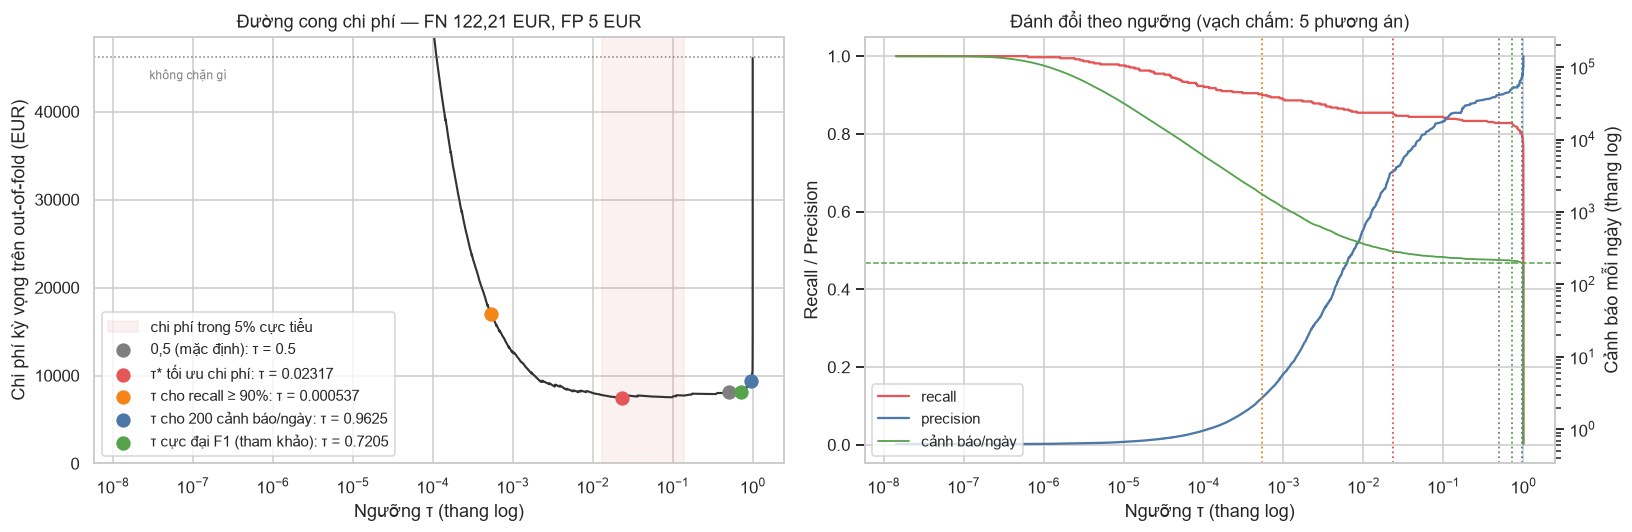

In [4]:
# Đường cong chi phí đầy đủ trên out-of-fold
duong = cost_curve(y_train, oof, thresholds=UNG_VIEN, cost_fn=DEFAULT_COST_FN,
                   cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN)
chi_phi_min = duong["expected_cost"].min()
vung_phang = duong[duong["expected_cost"] <= 1.05 * chi_phi_min]["threshold"]
chi_phi_05 = metrics_at_threshold(y_train, oof, NAIVE_THRESHOLD, sample_fraction=PHAN_TRAIN).expected_cost
chi_phi_bat_ca = duong["expected_cost"].iloc[0]                 # τ nhỏ nhất: chặn gần như tất cả
chi_phi_khong_chan = float(y_train.sum()) * DEFAULT_COST_FN     # không chặn gì

print(f"Chi phí cực tiểu (OOF)            : {chi_phi_min:,.0f} EUR tại τ* = {TAU_SAO:.5f}")
print(f"Chi phí tại τ = 0,5                : {chi_phi_05:,.0f} EUR (+{chi_phi_05 / chi_phi_min - 1:.1%})")
print(f"Không chặn gì (mất mọi vụ gian lận): {chi_phi_khong_chan:,.0f} EUR")
print(f"Vùng chi phí trong 5% cực tiểu     : τ từ {vung_phang.min():.4f} đến {vung_phang.max():.4f} "
      f"(rộng {vung_phang.max() / vung_phang.min():.0f} lần)")

fig, truc = plt.subplots(1, 2, figsize=(15, 5))
ax = truc[0]
ax.plot(duong["threshold"], duong["expected_cost"], c="#333333", lw=1.4)
ax.axvspan(vung_phang.min(), vung_phang.max(), color="#E45756", alpha=0.08,
           label="chi phí trong 5% cực tiểu")
for khoa, ten in TEN_PHUONG_AN.items():
    tau = phuong_an[khoa]
    c = metrics_at_threshold(y_train, oof, tau, sample_fraction=PHAN_TRAIN).expected_cost
    ax.scatter([tau], [c], s=70, color=MAU[ten], zorder=5, label=f"{ten}: τ = {tau:.4g}")
ax.set_xscale("log")
ax.set_ylim(0, chi_phi_khong_chan * 1.05)
ax.axhline(chi_phi_khong_chan, c="grey", ls=":", lw=1)
ax.text(duong["threshold"].min() * 2, chi_phi_khong_chan * 0.97, "không chặn gì", va="top",
        fontsize=8, color="grey")
ax.set_xlabel("Ngưỡng τ (thang log)")
ax.set_ylabel("Chi phí kỳ vọng trên out-of-fold (EUR)")
ax.set_title("Đường cong chi phí — FN 122,21 EUR, FP 5 EUR")
ax.legend(fontsize="small", loc="lower left")

ax = truc[1]
ax.plot(duong["threshold"], duong["recall"], c="#E45756", label="recall")
ax.plot(duong["threshold"], duong["precision"], c="#4C78A8", label="precision")
ax.set_xscale("log")
ax.set_xlabel("Ngưỡng τ (thang log)")
ax.set_ylabel("Recall / Precision")
ax2 = ax.twinx()
ax2.plot(duong["threshold"], duong["alerts_per_day"], c="#54A24B", lw=1.2, label="cảnh báo/ngày")
ax2.axhline(NGAN_SACH_CANH_BAO, c="#54A24B", ls="--", lw=1)
ax2.set_yscale("log")
ax2.set_ylabel("Cảnh báo mỗi ngày (thang log)")
ax2.grid(False)
for khoa, ten in TEN_PHUONG_AN.items():
    ax.axvline(phuong_an[khoa], color=MAU[ten], ls=":", lw=1.2)
dong1, nhan1 = ax.get_legend_handles_labels()
dong2, nhan2 = ax2.get_legend_handles_labels()
ax.legend(dong1 + dong2, nhan1 + nhan2, fontsize="small", loc="lower left")
ax.set_title("Đánh đổi theo ngưỡng (vạch chấm: 5 phương án)")
fig.tight_layout()
plots.save_fig(fig, "06_cost_curve.png")
plt.show()

**Nhận xét T-29 — τ\* = 0,0232, chọn trên out-of-fold; đáy đường chi phí phẳng.**

- **ML-08 được tôn trọng.** Cả năm ngưỡng chọn trên 226.980 điểm out-of-fold của tập huấn luyện.
  Tập kiểm thử chưa được nhìn tới trong mục này.
- **τ\* = 0,02317, chi phí OOF 7.407 EUR.** Giai đoạn 4 dùng lưới 200 điểm và được 0,02321, nên với
  riêng τ\* thì lưới thô không sao. Nhưng lưới thô **làm hỏng hai tiêu chí còn lại**:
  - *ngân sách 200 cảnh báo/ngày*: lưới chỉ tìm ra 172,5 cảnh báo/ngày, bỏ phí 14% năng lực thẩm
    định. Recall rơi từ 0,799 xuống 0,717, chi phí OOF tăng 3.728 EUR (9.373 → 13.101);
  - *max F1*: nhảy từ 0,72 lên 0,94. Đường F1 phẳng tới mức hai ngưỡng cách nhau 0,22 chỉ khác
    nhau 0,004 F1, nên nghiệm chính xác không có ý nghĩa ổn định. Đây là lý do `max_f1` chỉ để
    tham khảo.

  Vì vậy từ giai đoạn này mọi ngưỡng trong báo cáo dò trên **mọi điểm khác nhau**
  (`thresholds=np.unique(oof)`, 0,3 giây). API vẫn dùng lưới 200 điểm cho thanh trượt.
- **Đáy phẳng.** Mọi τ từ 0,013 tới 0,140 (rộng **11 lần**) đều cho chi phí trong 5% cực tiểu.
  Khuyến nghị "τ\* = 0,0232" vì thế không nhạy với chữ số thứ ba. Đó là điều tốt cho vận hành.
- **0,5 không tệ như 04 §6.1 dự báo, và cần giải thích vì sao.** 04 §6.1 nói ngưỡng 0,5 làm recall
  "thấp bất thường". Điều đó đúng với mô hình học trên dữ liệu mất cân bằng mà *không* có trọng
  số lớp. Ở đây `scale_pos_weight = 599,5` đã đẩy điểm của lớp dương lên sát 1. Kết quả là τ = 0,5
  cho recall OOF 0,828, chỉ kém τ\* 0,026, và đắt hơn 9,5%. Giai đoạn 3 đã thấy trọng số lớp
  "dịch điểm chứ không đổi thứ tự"; ở đây là hệ quả của nó: trọng số lớp đã làm hộ một phần việc
  của ngưỡng.
- **Hai phương án có ràng buộc đắt hơn nhiều.** Recall ≥ 90% cần τ = 0,00054. Mức đó đòi 1.772
  cảnh báo mỗi ngày, gấp 9 lần năng lực thẩm định, và chi phí OOF gấp 2,3 lần τ\*.

---
## 3. Bảng bắt buộc — T-30

Các ngưỡng đã chốt ở §2 giờ mới được đưa ra **tập kiểm thử**. Mỗi recall và precision kèm khoảng
tin cậy bootstrap phân tầng 1.000 lần tại ngưỡng **cố định** (không dò lại trong từng lần lặp).

Cảnh báo/ngày quy đổi từ tập kiểm thử (20% của hai ngày) ra toàn luồng: `cảnh báo / 0,2 / 2`.

In [5]:
bang = compare_thresholds(y_test, diem_test, phuong_an, cost_fn=DEFAULT_COST_FN,
                          cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TEST)
bang_oof = compare_thresholds(y_train, oof, phuong_an, cost_fn=DEFAULT_COST_FN,
                              cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN)
bang["phương án"] = bang["name"].map(TEN_PHUONG_AN)
bang = bang.set_index("name").loc[list(TEN_PHUONG_AN)].reset_index()

for chi_so in ("recall", "precision"):
    ci = [bootstrap_ci(y_test, diem_test, chi_so, threshold=t, n_boot=N_BOOT, random_state=RANDOM_STATE)
          for t in bang["threshold"]]
    bang[f"{chi_so}_ci_low"] = [c["ci_low"] for c in ci]
    bang[f"{chi_so}_ci_high"] = [c["ci_high"] for c in ci]
bang["recall_oof"] = bang["name"].map(bang_oof.set_index("name")["recall"])
bang["alerts_per_day_oof"] = bang["name"].map(bang_oof.set_index("name")["alerts_per_day"])
bang.to_csv(REPORTS_DIR / "threshold_comparison.csv", index=False, encoding="utf-8")

hien = pd.DataFrame({
    "Ngưỡng": bang["phương án"],
    "τ": bang["threshold"].map("{:.4g}".format),
    "Cảnh báo/ngày": bang["alerts_per_day"].map("{:,.0f}".format),
    "TP": bang["tp"], "FP": bang["fp"], "FN": bang["fn"],
    "Precision [KTC 95%]": bang.apply(lambda r: f"{r['precision']:.3f} [{r['precision_ci_low']:.3f} – {r['precision_ci_high']:.3f}]", axis=1),
    "Recall [KTC 95%]": bang.apply(lambda r: f"{r['recall']:.3f} [{r['recall_ci_low']:.3f} – {r['recall_ci_high']:.3f}]", axis=1),
    "Chi phí kỳ vọng": bang["expected_cost"].map("{:,.0f} EUR".format),
})
print("Tập kiểm thử — 56.746 giao dịch, 95 gian lận; ngưỡng chọn trên out-of-fold")
display(hien.style.hide(axis="index"))

print("Ràng buộc chọn trên out-of-fold có giữ được trên tập kiểm thử không?")
display(pd.DataFrame({
    "phương án": bang["phương án"],
    "recall OOF": bang["recall_oof"].round(3), "recall test": bang["recall"].round(3),
    "cảnh báo/ngày OOF": bang["alerts_per_day_oof"].round(1), "cảnh báo/ngày test": bang["alerts_per_day"].round(1),
}).style.hide(axis="index"))

Tập kiểm thử — 56.746 giao dịch, 95 gian lận; ngưỡng chọn trên out-of-fold


Ngưỡng,τ,Cảnh báo/ngày,TP,FP,FN,Precision [KTC 95%],Recall [KTC 95%],Chi phí kỳ vọng
"0,5 (mặc định)",0.5,195,74,4,21,0.949 [0.899 – 0.987],0.779 [0.695 – 0.863],"2,586 EUR"
τ* tối ưu chi phí,0.02317,287,77,38,18,0.670 [0.600 – 0.752],0.811 [0.737 – 0.884],"2,390 EUR"
τ cho recall ≥ 90%,0.000537,"2,007",83,720,12,0.103 [0.094 – 0.114],0.874 [0.811 – 0.937],"5,067 EUR"
τ cho 200 cảnh báo/ngày,0.9625,175,69,1,26,0.986 [0.956 – 1.000],0.726 [0.642 – 0.811],"3,182 EUR"
τ cực đại F1 (tham khảo),0.7205,190,73,3,22,0.961 [0.915 – 1.000],0.768 [0.684 – 0.853],"2,704 EUR"


Ràng buộc chọn trên out-of-fold có giữ được trên tập kiểm thử không?


phương án,recall OOF,recall test,cảnh báo/ngày OOF,cảnh báo/ngày test
"0,5 (mặc định)",0.828000,0.779000,216.900000,195.000000
τ* tối ưu chi phí,0.854000,0.811000,287.500000,287.500000
τ cho recall ≥ 90%,0.902000,0.874000,1772.500000,2007.500000
τ cho 200 cảnh báo/ngày,0.799000,0.726000,199.400000,175.000000
τ cực đại F1 (tham khảo),0.828000,0.768000,213.100000,190.000000


In [6]:
# Đoạn diễn giải bằng lời (04 §6.4) — kèm khoảng tin cậy theo cặp cho từng con số
hieu = bootstrap_threshold_diff(y_test, diem_test, TAU_SAO, NAIVE_THRESHOLD, cost_fn=DEFAULT_COST_FN,
                                cost_fp=DEFAULT_COST_FP, n_boot=N_BOOT, random_state=RANDOM_STATE)
theo_ngay = 1 / PHAN_TEST / DATASET_DAYS
m05 = metrics_at_threshold(y_test, diem_test, NAIVE_THRESHOLD, sample_fraction=PHAN_TEST)
msao = metrics_at_threshold(y_test, diem_test, TAU_SAO, sample_fraction=PHAN_TEST)

def khoang(h, he_so=1.0, dang="{:+.0f}"):
    return f"{dang.format(h['value'] * he_so)} [{dang.format(h['ci_low'] * he_so)}, {dang.format(h['ci_high'] * he_so)}]"

print(f"Trên tập kiểm thử (20% của hai ngày), hạ ngưỡng từ 0,5 xuống τ* = {TAU_SAO:.4f}:")
print(f"  bắt thêm        {khoang(hieu['tp'])} vụ gian lận   ({m05.tp} → {msao.tp} trên 95)")
print(f"  thêm            {khoang(hieu['fp'])} cảnh báo giả  ({m05.fp} → {msao.fp})")
print(f"  chi phí đổi     {khoang(hieu['cost'], dang='{:+,.0f}')} EUR   "
      f"({m05.expected_cost:,.0f} → {msao.expected_cost:,.0f})")
print(f"  τ* rẻ hơn 0,5 ở {hieu['cost']['a_cheaper']:.0%} số lần lặp bootstrap; KTC của hiệu chi phí "
      f"chứa 0: {hieu['cost']['contains_zero']}")
print()
print(f"Quy ra một ngày trên toàn luồng (× {theo_ngay:.1f}): bắt thêm {hieu['tp']['value'] * theo_ngay:.1f} vụ, "
      f"thêm {hieu['fp']['value'] * theo_ngay:.1f} cảnh báo giả, tiết kiệm ròng "
      f"{-hieu['cost']['value'] * theo_ngay:,.0f} EUR/ngày "
      f"[{-hieu['cost']['ci_high'] * theo_ngay:,.0f}, {-hieu['cost']['ci_low'] * theo_ngay:,.0f}]")

# Cùng phép so trên out-of-fold: 378 gian lận thay vì 95, và là nơi ngưỡng thật sự được chọn
hieu_oof = bootstrap_threshold_diff(y_train, oof, TAU_SAO, NAIVE_THRESHOLD, cost_fn=DEFAULT_COST_FN,
                                    cost_fp=DEFAULT_COST_FP, n_boot=N_BOOT, random_state=RANDOM_STATE)
print()
print(f"Trên out-of-fold ({int(y_train.sum())} gian lận): bắt thêm {khoang(hieu_oof['tp'])} vụ, "
      f"thêm {khoang(hieu_oof['fp'])} cảnh báo giả, chi phí đổi {khoang(hieu_oof['cost'], dang='{:+,.0f}')} EUR; "
      f"τ* rẻ hơn ở {hieu_oof['cost']['a_cheaper']:.1%} số lần lặp, KTC chứa 0: {hieu_oof['cost']['contains_zero']}")

Trên tập kiểm thử (20% của hai ngày), hạ ngưỡng từ 0,5 xuống τ* = 0.0232:
  bắt thêm        +3 [+0, +7] vụ gian lận   (74 → 77 trên 95)
  thêm            +34 [+23, +45] cảnh báo giả  (4 → 38)
  chi phí đổi     -197 [-676, +160] EUR   (2,586 → 2,390)
  τ* rẻ hơn 0,5 ở 83% số lần lặp bootstrap; KTC của hiệu chi phí chứa 0: True

Quy ra một ngày trên toàn luồng (× 2.5): bắt thêm 7.5 vụ, thêm 85.0 cảnh báo giả, tiết kiệm ròng 492 EUR/ngày [-400, 1,689]



Trên out-of-fold (378 gian lận): bắt thêm +10 [+4, +17] vụ, thêm +103 [+84, +122] cảnh báo giả, chi phí đổi -707 [-1,513, -24] EUR; τ* rẻ hơn ở 97.8% số lần lặp, KTC chứa 0: False


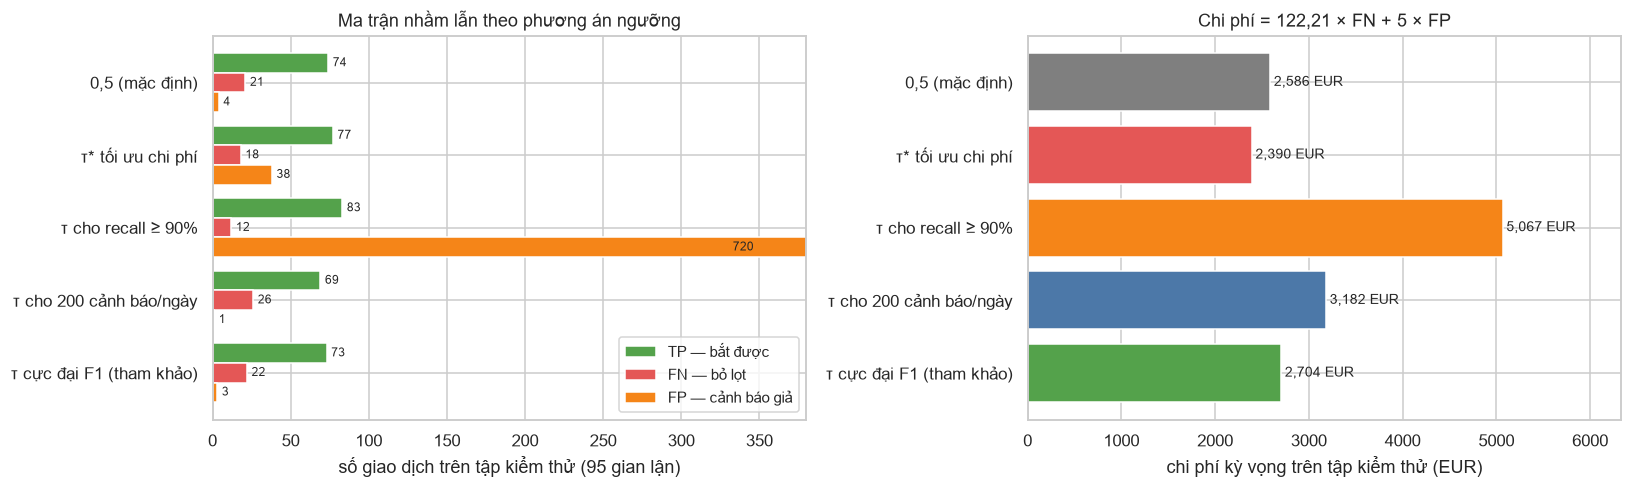

In [7]:
fig, truc = plt.subplots(1, 2, figsize=(15, 4.6))
ten = bang["phương án"]
y = np.arange(len(bang))
ax = truc[0]
ax.barh(y - 0.27, bang["tp"], height=0.27, color="#54A24B", label="TP — bắt được")
ax.barh(y, bang["fn"], height=0.27, color="#E45756", label="FN — bỏ lọt")
ax.barh(y + 0.27, bang["fp"], height=0.27, color="#F58518", label="FP — cảnh báo giả")
for yi, (tp, fn, fp) in enumerate(zip(bang["tp"], bang["fn"], bang["fp"])):
    ax.text(tp + 3, yi - 0.27, str(tp), va="center", fontsize=8)
    ax.text(fn + 3, yi, str(fn), va="center", fontsize=8)
    ax.text(min(fp, 330) + 3, yi + 0.27, str(fp), va="center", fontsize=8)
ax.set_xlim(0, 380)
ax.set_yticks(y, ten)
ax.invert_yaxis()
ax.set_xlabel("số giao dịch trên tập kiểm thử (95 gian lận)")
ax.set_title("Ma trận nhầm lẫn theo phương án ngưỡng")
ax.legend(fontsize="small", loc="lower right")

ax = truc[1]
ax.barh(y, bang["expected_cost"], color=[MAU[t] for t in ten])
for yi, c in enumerate(bang["expected_cost"]):
    ax.text(c + 40, yi, f"{c:,.0f} EUR", va="center", fontsize=9)
ax.set_yticks(y, ten)
ax.invert_yaxis()
ax.set_xlim(0, bang["expected_cost"].max() * 1.25)
ax.set_xlabel("chi phí kỳ vọng trên tập kiểm thử (EUR)")
ax.set_title("Chi phí = 122,21 × FN + 5 × FP")
fig.tight_layout()
plots.save_fig(fig, "06_threshold_options.png")
plt.show()

**Nhận xét T-30.**

| Ngưỡng | τ | Cảnh báo/ngày | TP | FP | FN | Precision | Recall | Chi phí kỳ vọng |
|---|---|---|---|---|---|---|---|---|
| 0,5 (mặc định) | 0,5 | 195 | 74 | 4 | 21 | 0,949 | 0,779 | 2.586 EUR |
| **τ\* tối ưu chi phí** | **0,0232** | **287** | **77** | **38** | **18** | **0,670** | **0,811** | **2.390 EUR** |
| τ cho recall ≥ 90% | 0,00054 | 2.007 | 83 | 720 | 12 | 0,103 | 0,874 | 5.067 EUR |
| τ cho 200 cảnh báo/ngày | 0,9625 | 175 | 69 | 1 | 26 | 0,986 | 0,726 | 3.182 EUR |

**Diễn giải bằng lời.** *Hạ ngưỡng từ 0,5 xuống τ\* = 0,0232 bắt thêm **3** vụ gian lận trên tập
kiểm thử (74 → 77 trên 95), đổi lại **34** cảnh báo giả (4 → 38), tiết kiệm ròng **197 EUR**
(2.586 → 2.390). Quy ra toàn luồng, mỗi ngày bắt thêm khoảng 7,5 vụ, nhận thêm 85 cảnh báo giả và
tiết kiệm ròng khoảng 490 EUR.*

**Nhưng phải nói kèm độ chắc chắn.**

- **Trên tập kiểm thử, khoản tiết kiệm KHÔNG có ý nghĩa thống kê.** Bootstrap theo cặp cho hiệu chi
  phí −197 EUR [−676, +160]. Khoảng tin cậy chứa 0, và τ\* rẻ hơn ở 83% số lần lặp. Ba vụ bắt thêm
  có khoảng tin cậy [0, 7]. Với 95 mẫu dương, ba vụ không đủ để phân định.
- **Trên out-of-fold, nơi ngưỡng được chọn, khoản tiết kiệm có ý nghĩa.** Với 378 gian lận: bắt
  thêm 10 [4, 17] vụ, thêm 103 cảnh báo giả, chi phí −707 EUR [−1.513, −24]. τ\* rẻ hơn ở 97,8% số
  lần lặp. Kết luận "τ\* tốt hơn 0,5" dựa vào con số này. Tập kiểm thử chỉ xác nhận **cùng chiều**,
  không đủ lực để tự chứng minh.
- **Ràng buộc chọn trên OOF không tự động đúng trên dữ liệu mới.**
  - *Recall ≥ 90%* đạt 0,902 trên OOF nhưng chỉ **0,874** trên test (thiếu 3 vụ). KTC
    [0,811 – 0,937] vẫn chứa 0,90, nhưng nếu đây là ràng buộc tuân thủ thật thì phải chọn τ có biên
    an toàn, chứ không lấy τ vừa khít trên OOF.
  - *Ngân sách 200 cảnh báo/ngày* giữ được: 199,4 trên OOF, 175 trên test.
- **Hệ quả vận hành quan trọng nhất: τ\* vượt năng lực thẩm định 44%.** τ\* sinh khoảng 287 cảnh báo
  mỗi ngày. Nếu đội thẩm định thật sự chỉ xử lý được 200, phương án khả thi là τ = 0,9625: bỏ lọt thêm
  8 vụ so với τ\* và đắt hơn 792 EUR trên tập test. Đây là **giá của thiếu nhân lực**, và là con số
  đáng đưa cho người ra quyết định: thêm khoảng 110 lượt thẩm định mỗi ngày (175 → 287 trên tập test) thì bắt
  thêm khoảng 20 vụ gian lận mỗi ngày (8 vụ trên 20% dữ liệu của hai ngày).

---
## 4. Độ nhạy theo tỷ lệ chi phí — T-31

`cost_fn = 122,21` (trung bình số tiền gian lận) và `cost_fp = 5` (công thẩm định) đều là giả định
(A-01, A-02). Giữ `cost_fp = 5` và cho tỷ lệ `cost_fn : cost_fp` chạy từ **5:1 tới 100:1**. Với mỗi
tỷ lệ, τ\* chọn lại trên out-of-fold rồi đo trên tập kiểm thử.

Thêm một câu hỏi thực dụng hơn: nếu cứ dùng τ\* của tỷ lệ mặc định 24,4:1 trong khi tỷ lệ **thật** là
r, thì mất thêm bao nhiêu so với việc biết đúng r? Đó là **độ hối tiếc** (regret) — con số cho biết
sai giả định chi phí đắt tới đâu.

In [8]:
TY_LE = (5, 7.5, 10, 15, 20, round(TY_LE_MAC_DINH, 2), 30, 40, 50, 75, 100)
nhay = sensitivity_analysis(y_train, oof, ratios=TY_LE, cost_fp=DEFAULT_COST_FP,
                            thresholds=UNG_VIEN, sample_fraction=PHAN_TRAIN)

hang = []
for _, r in nhay.iterrows():
    kw = dict(cost_fn=r["cost_fn"], cost_fp=r["cost_fp"])
    t_test = metrics_at_threshold(y_test, diem_test, r["threshold"], sample_fraction=PHAN_TEST, **kw)
    # Độ hối tiếc: dùng τ* mặc định khi tỷ lệ thật là r (tính trên OOF, nơi chọn ngưỡng)
    c_mac_dinh = metrics_at_threshold(y_train, oof, TAU_SAO, sample_fraction=PHAN_TRAIN, **kw).expected_cost
    hang.append({"recall_test": t_test.recall, "precision_test": t_test.precision, "tp_test": t_test.tp,
                 "fp_test": t_test.fp, "fn_test": t_test.fn, "alerts_per_day_test": t_test.alerts_per_day,
                 "cost_test": t_test.expected_cost,
                 "regret_oof": c_mac_dinh / r["expected_cost"] - 1})
nhay = pd.concat([nhay, pd.DataFrame(hang)], axis=1)
nhay.to_csv(REPORTS_DIR / "cost_sensitivity.csv", index=False, encoding="utf-8")

display(pd.DataFrame({
    "FN:FP": nhay["cost_ratio"].map("{:g}:1".format),
    "cost_fn": nhay["cost_fn"].map("{:.2f}".format),
    "τ* (OOF)": nhay["threshold"].map("{:.5f}".format),
    "recall OOF": nhay["recall"].round(3),
    "cảnh báo/ngày OOF": nhay["alerts_per_day"].round(0),
    "recall test": nhay["recall_test"].round(3),
    "precision test": nhay["precision_test"].round(3),
    "TP / FP / FN test": nhay.apply(lambda r: f"{r['tp_test']:.0f} / {r['fp_test']:.0f} / {r['fn_test']:.0f}", axis=1),
    "hối tiếc nếu giữ τ* mặc định": nhay["regret_oof"].map("{:+.1%}".format),
}).style.hide(axis="index"))

on_dinh = nhay[np.isclose(nhay["threshold"], TAU_SAO)]["cost_ratio"]
print(f"τ* giữ nguyên {TAU_SAO:.5f} trên dải tỷ lệ {on_dinh.min():g}:1 → {on_dinh.max():g}:1")
print(f"Dải τ* trên toàn bộ 5:1 → 100:1: {nhay['threshold'].min():.5f} → {nhay['threshold'].max():.4f} "
      f"(gấp {nhay['threshold'].max() / nhay['threshold'].min():,.0f} lần)")
print(f"Hối tiếc lớn nhất khi giữ τ* mặc định: {nhay['regret_oof'].max():.1%} "
      f"(ở tỷ lệ {nhay.loc[nhay['regret_oof'].idxmax(), 'cost_ratio']:g}:1)")

FN:FP,cost_fn,τ* (OOF),recall OOF,cảnh báo/ngày OOF,recall test,precision test,TP / FP / FN test,hối tiếc nếu giữ τ* mặc định
5:1,25.00,0.72051,0.828000,213.000000,0.768000,0.961000,73 / 3 / 22,+16.7%
7.5:1,37.50,0.09857,0.844000,239.000000,0.800000,0.844000,76 / 14 / 19,+8.5%
10:1,50.00,0.09857,0.844000,239.000000,0.800000,0.844000,76 / 14 / 19,+5.0%
15:1,75.00,0.09857,0.844000,239.000000,0.800000,0.844000,76 / 14 / 19,+1.4%
20:1,100.00,0.02317,0.854000,288.000000,0.811000,0.670000,77 / 38 / 18,+0.0%
24.44:1,122.20,0.02317,0.854000,288.000000,0.811000,0.670000,77 / 38 / 18,+0.0%
30:1,150.00,0.02317,0.854000,288.000000,0.811000,0.670000,77 / 38 / 18,+0.0%
40:1,200.00,0.02317,0.854000,288.000000,0.811000,0.670000,77 / 38 / 18,+0.0%
50:1,250.00,0.02317,0.854000,288.000000,0.811000,0.670000,77 / 38 / 18,+0.0%
75:1,375.00,0.00226,0.884000,697.000000,0.853000,0.263000,81 / 227 / 14,+4.4%


τ* giữ nguyên 0.02317 trên dải tỷ lệ 20:1 → 50:1
Dải τ* trên toàn bộ 5:1 → 100:1: 0.00226 → 0.7205 (gấp 319 lần)
Hối tiếc lớn nhất khi giữ τ* mặc định: 16.7% (ở tỷ lệ 5:1)


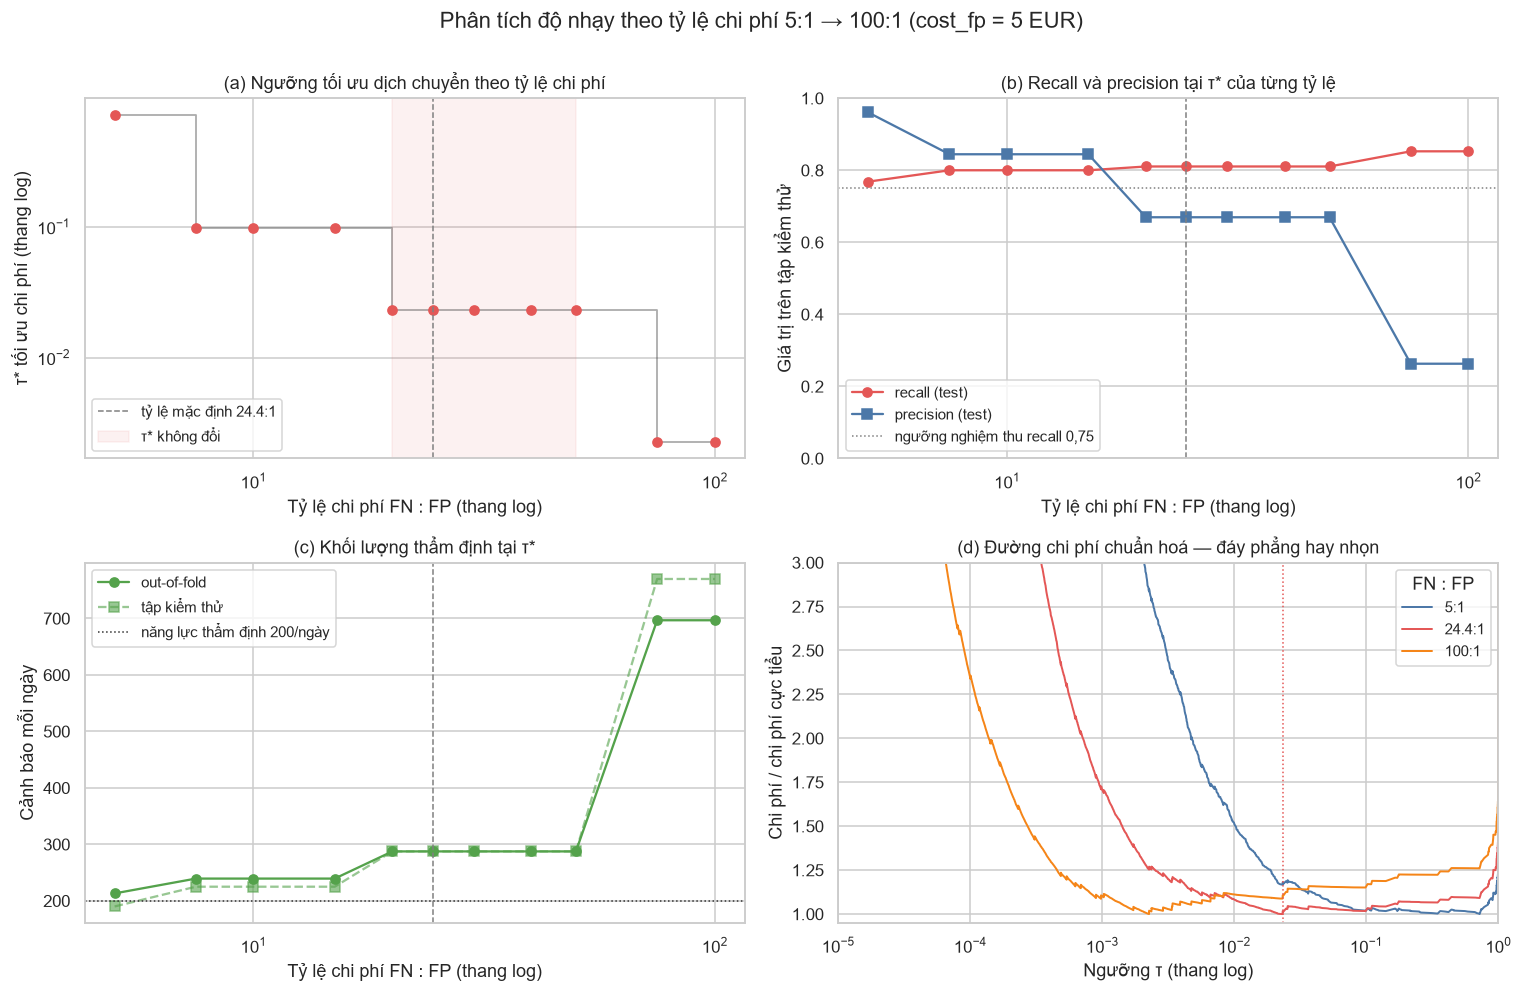

In [9]:
fig, truc = plt.subplots(2, 2, figsize=(14, 9))
r = nhay["cost_ratio"]

ax = truc[0, 0]
ax.step(r, nhay["threshold"], where="post", c="#333333", lw=1.2, alpha=0.4)
ax.plot(r, nhay["threshold"], "o", c="#E45756")
ax.axvline(TY_LE_MAC_DINH, c="grey", ls="--", lw=1, label=f"tỷ lệ mặc định {TY_LE_MAC_DINH:.1f}:1")
ax.axvspan(on_dinh.min(), on_dinh.max(), color="#E45756", alpha=0.08, label="τ* không đổi")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Tỷ lệ chi phí FN : FP (thang log)")
ax.set_ylabel("τ* tối ưu chi phí (thang log)")
ax.set_title("(a) Ngưỡng tối ưu dịch chuyển theo tỷ lệ chi phí")
ax.legend(fontsize="small")

ax = truc[0, 1]
ax.plot(r, nhay["recall_test"], "o-", c="#E45756", label="recall (test)")
ax.plot(r, nhay["precision_test"], "s-", c="#4C78A8", label="precision (test)")
ax.axvline(TY_LE_MAC_DINH, c="grey", ls="--", lw=1)
ax.axhline(0.75, c="grey", ls=":", lw=1, label="ngưỡng nghiệm thu recall 0,75")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("Tỷ lệ chi phí FN : FP (thang log)")
ax.set_ylabel("Giá trị trên tập kiểm thử")
ax.set_title("(b) Recall và precision tại τ* của từng tỷ lệ")
ax.legend(fontsize="small")

ax = truc[1, 0]
ax.plot(r, nhay["alerts_per_day"], "o-", c="#54A24B", label="out-of-fold")
ax.plot(r, nhay["alerts_per_day_test"], "s--", c="#54A24B", alpha=0.6, label="tập kiểm thử")
ax.axhline(NGAN_SACH_CANH_BAO, c="#333333", ls=":", lw=1, label="năng lực thẩm định 200/ngày")
ax.axvline(TY_LE_MAC_DINH, c="grey", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Tỷ lệ chi phí FN : FP (thang log)")
ax.set_ylabel("Cảnh báo mỗi ngày")
ax.set_title("(c) Khối lượng thẩm định tại τ*")
ax.legend(fontsize="small")

ax = truc[1, 1]
for ty_le, mau in ((5, "#4C78A8"), (TY_LE_MAC_DINH, "#E45756"), (100, "#F58518")):
    d = cost_curve(y_train, oof, thresholds=UNG_VIEN, cost_fn=DEFAULT_COST_FP * ty_le,
                   cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN)
    ax.plot(d["threshold"], d["expected_cost"] / d["expected_cost"].min(), c=mau, lw=1.3,
            label=f"{ty_le:.3g}:1")
ax.axvline(TAU_SAO, c="#E45756", ls=":", lw=1)
ax.set_xscale("log")
ax.set_ylim(0.95, 3)
ax.set_xlim(1e-5, 1)
ax.set_xlabel("Ngưỡng τ (thang log)")
ax.set_ylabel("Chi phí / chi phí cực tiểu")
ax.set_title("(d) Đường chi phí chuẩn hoá — đáy phẳng hay nhọn")
ax.legend(title="FN : FP", fontsize="small")

fig.suptitle("Phân tích độ nhạy theo tỷ lệ chi phí 5:1 → 100:1 (cost_fp = 5 EUR)", y=1.0)
fig.tight_layout()
plots.save_fig(fig, "06_cost_sensitivity.png")
plt.show()

**Nhận xét T-31 — khuyến nghị vững trong dải 10:1 → 75:1. Tỷ lệ chi phí quyết định khối lượng
thẩm định, không quyết định recall.**

1. **τ\* đổi theo bậc, không trượt liên tục.** Đi từ 5:1 tới 100:1, τ\* chỉ nhận 4 giá trị: 0,72
   (5:1), 0,099 (7,5–15:1), **0,0232 (20–50:1)** và 0,0023 (75–100:1). Tỷ lệ mặc định 24,4:1 nằm
   gần giữa bậc 20–50:1. Muốn τ\* đổi thì ước lượng `cost_fn` phải sai tới mức dưới 100 EUR hoặc
   trên 250 EUR, tức lệch hơn 20% về phía dưới hoặc gấp đôi về phía trên.
2. **Sai giả định chi phí thì mất ít.** Cột "hối tiếc" trả lời: nếu cứ dùng τ\* = 0,0232 mà tỷ lệ
   thật là r, thì đắt hơn τ\* đúng của r bao nhiêu? Kết quả ≤ 5% cho mọi r từ 10:1 tới 75:1, 8,8%
   ở 100:1 và 16,7% ở 5:1. Hình (d) cho thấy lý do: đáy của mỗi đường chi phí rộng hàng chục lần
   theo τ.
3. **Recall trên tập kiểm thử gần như không đổi.** Suốt dải 5:1 → 100:1, recall chỉ đi từ 0,768 tới
   0,853 và luôn ≥ 0,75 (AC-M2 đứng vững bất kể giả định chi phí). Thứ thay đổi mạnh là
   **precision (0,96 → 0,26)** và **số cảnh báo mỗi ngày (khoảng 190 → 770)**. Nói cách khác,
   ở vùng này đường PR gần như nằm ngang: muốn bắt thêm vài vụ cuối cùng thì phải trả bằng hàng trăm
   cảnh báo giả. Câu hỏi thật của người quản lý rủi ro không phải "gian lận đắt bao nhiêu", mà
   "đội thẩm định chịu được bao nhiêu cảnh báo".
4. **Nguồn bất định lớn hơn nằm ở thời gian, không ở chi phí.** T-27 cho thấy cùng τ\* nhưng sang
   ngày 2 thì báo động giả tăng 3,6 lần. Mức đó tương đương dịch cả một bậc trong bảng trên. Vì
   vậy ngưỡng phải chỉnh được lúc chạy (UI-03) và phải theo dõi số cảnh báo/ngày, chứ không chỉ
   chọn một lần.

**AC-M8 đạt:** có bảng, có hình, và kết luận nói rõ khuyến nghị phụ thuộc vào giả định chi phí tới
đâu.

---
## 5. Tổng kết giai đoạn 5 — phần ngưỡng

| Việc | Kết quả | Trạng thái |
|---|---|---|
| T-29 | τ\* = 0,02317 chọn trên out-of-fold (ML-08). Đáy chi phí phẳng: τ ∈ [0,013; 0,140] đều trong 5% cực tiểu. Lưới 200 điểm làm hỏng tiêu chí ngân sách (172 thay vì 199 cảnh báo/ngày), nên báo cáo dò trên mọi điểm | ✅ |
| T-30 | bảng 4 ngưỡng + câu diễn giải: 0,5 → τ\* bắt thêm 3 vụ, thêm 34 cảnh báo giả, tiết kiệm 197 EUR trên test (KTC chứa 0); trên OOF tiết kiệm 707 EUR [24; 1.513] | ✅ |
| T-31 | τ\* ổn định ở 20:1 – 50:1, hối tiếc ≤ 5% trong 10:1 – 75:1, recall test luôn ≥ 0,75 | ✅ AC-M8 |

**Mang sang các giai đoạn sau:**

- `models/threshold.json` (T-36): τ mặc định = **0,02317**, kèm 4 phương án ở bảng trên và
  `cost_fn = 122,21`, `cost_fp = 5`.
- τ\* sinh khoảng 287 cảnh báo/ngày, vượt ngân sách 200. Màn hình UI-03 phải hiện số cảnh
  báo/ngày cạnh chi phí, để người dùng thấy ngay khi vượt năng lực thẩm định.
- Ràng buộc recall chọn vừa khít trên OOF thì hụt trên dữ liệu mới (0,902 → 0,874). Phần hạn chế
  của báo cáo cần nêu điều này.

---
## 6. Bổ sung sau rà soát — chi phí theo số tiền, ngưỡng đề xuất chặn, điểm rủi ro có phải xác suất

Ba câu hỏi mà mục 2–4 chưa trả lời, phát sinh khi rà soát dự án:

1. **Giả định chi phí bỏ lọt (6.1).** Mục 2–4 tính mọi vụ bỏ lọt bằng cùng một con số 122,21 EUR. Con số
   đó lấy từ đâu? Và nếu tính đúng số tiền của từng vụ bị lọt, câu "hạ ngưỡng 0,5 → τ\* tiết kiệm tiền"
   còn đứng không?
2. **Ngưỡng đề xuất chặn của API (6.2).** Thiết kế cũ chặn tự động khi điểm ≥ 3τ. Bội số 3 không dựa trên
   phân tích nào; chọn lại theo precision trên out-of-fold.
3. **Điểm rủi ro có dùng như xác suất được không (6.3)?** Mô hình huấn luyện với `scale_pos_weight` ≈ 599.

Quy tắc như mọi mục khác: **chọn** trên out-of-fold, tập kiểm thử chỉ để **đo** (ML-08).

In [10]:
# 6.1a — 122,21 EUR (DEFAULT_COST_FN) là trung bình Amount của gian lận trên dữ liệu THÔ — gồm cả tập
# kiểm thử và 1.081 dòng trùng lặp (TASKS.md, ghi chú giai đoạn 1: thô 122,21 / sau loại trùng 123,87).
# Đúng quy tắc thì tham số nào cũng chỉ được ước lượng trên tập huấn luyện. Dùng con số "sạch" thì τ* có đổi không?
# (Không nạp lại dữ liệu thô ở đây: notebook huấn luyện chỉ được nạp qua load_prepared — test_no_leakage.)
from src.threshold import pick_threshold

nguon_chi_phi = pd.DataFrame([
    {"nguồn của cost_fn": "dữ liệu thô — con số đang dùng (DEFAULT_COST_FN)", "cost_fn": DEFAULT_COST_FN},
    {"nguồn của cost_fn": "sau khi loại trùng lặp", "cost_fn": df.loc[df["Class"] == 1, "Amount"].mean()},
    {"nguồn của cost_fn": "chỉ tập huấn luyện", "cost_fn": X_train.loc[y_train == 1, "Amount"].mean()},
])
nguon_chi_phi["τ* trên out-of-fold"] = [
    pick_threshold(y_train, oof, "min_expected_cost", cost_fn=c, cost_fp=DEFAULT_COST_FP,
                   thresholds=UNG_VIEN, sample_fraction=PHAN_TRAIN)
    for c in nguon_chi_phi["cost_fn"]
]
display(nguon_chi_phi.style.format({"cost_fn": "{:.2f} EUR", "τ* trên out-of-fold": "{:.6f}"}).hide(axis="index"))
print("τ* không đổi:", nguon_chi_phi["τ* trên out-of-fold"].nunique() == 1)

nguồn của cost_fn,cost_fn,τ* trên out-of-fold
dữ liệu thô — con số đang dùng (DEFAULT_COST_FN),122.21 EUR,0.023173
sau khi loại trùng lặp,123.87 EUR,0.023173
chỉ tập huấn luyện,115.94 EUR,0.023173


τ* không đổi: True


In [11]:
# 6.1b — Chi phí bỏ lọt = SỐ TIỀN của chính vụ bị lọt; chi phí thẩm định vẫn 5 EUR mỗi cảnh báo.
# Cùng điểm out-of-fold, cùng tập ứng viên; chỉ đổi hàm chi phí.
SO_TIEN_TRAIN = X_train["Amount"].to_numpy()
SO_TIEN_TEST = X_test["Amount"].to_numpy()

TAU_SO_TIEN = pick_threshold(y_train, oof, "min_expected_cost", cost_fp=DEFAULT_COST_FP,
                             fn_costs=SO_TIEN_TRAIN, thresholds=UNG_VIEN, sample_fraction=PHAN_TRAIN)
NGUONG_SO_SANH = {"0,5 (mặc định)": NAIVE_THRESHOLD, "τ* — chi phí cố định": TAU_SAO,
                  "τ*ₐ — chi phí theo số tiền": TAU_SO_TIEN}
print(f"τ*ₐ (chi phí theo số tiền, chọn trên out-of-fold) = {TAU_SO_TIEN:.6f}   (τ* = {TAU_SAO:.6f})")

dong = []
for tap, y, s, a, phan in (("out-of-fold", y_train, oof, SO_TIEN_TRAIN, PHAN_TRAIN),
                           ("kiểm thử", y_test, diem_test, SO_TIEN_TEST, PHAN_TEST)):
    for ten, t in NGUONG_SO_SANH.items():
        co_dinh = metrics_at_threshold(y, s, t, cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP, sample_fraction=phan)
        theo_tien = metrics_at_threshold(y, s, t, cost_fp=DEFAULT_COST_FP, sample_fraction=phan, fn_costs=a)
        dong.append({"tập": tap, "ngưỡng": ten, "τ": t, "TP": co_dinh.tp, "FP": co_dinh.fp, "FN": co_dinh.fn,
                     "cảnh báo/ngày": co_dinh.alerts_per_day,
                     "tiền gian lận bị lọt": theo_tien.expected_cost - co_dinh.fp * DEFAULT_COST_FP,
                     "chi phí — cố định 122,21": co_dinh.expected_cost,
                     "chi phí — theo số tiền": theo_tien.expected_cost})
so_tien = pd.DataFrame(dong)
so_tien.to_csv(REPORTS_DIR / "amount_cost_comparison.csv", index=False, encoding="utf-8")
display(so_tien.style.format({"τ": "{:.5f}", "cảnh báo/ngày": "{:,.0f}", "tiền gian lận bị lọt": "{:,.2f}",
                              "chi phí — cố định 122,21": "{:,.2f}", "chi phí — theo số tiền": "{:,.2f}"})
        .hide(axis="index"))

τ*ₐ (chi phí theo số tiền, chọn trên out-of-fold) = 0.006597   (τ* = 0.023173)


tập,ngưỡng,τ,TP,FP,FN,cảnh báo/ngày,tiền gian lận bị lọt,"chi phí — cố định 122,21",chi phí — theo số tiền
out-of-fold,"0,5 (mặc định)",0.50000,313,34,65,217,"10,735.46","8,113.65","10,905.46"
out-of-fold,τ* — chi phí cố định,0.02317,323,137,55,288,"10,429.90","7,406.55","11,114.90"
out-of-fold,τ*ₐ — chi phí theo số tiền,0.00660,326,350,52,423,"9,123.30","8,104.92","10,873.30"
kiểm thử,"0,5 (mặc định)",0.50000,74,4,21,195,"3,792.56","2,586.41","3,812.56"
kiểm thử,τ* — chi phí cố định,0.02317,77,38,18,287,"3,782.79","2,389.78","3,972.79"
kiểm thử,τ*ₐ — chi phí theo số tiền,0.00660,78,89,17,417,"3,331.52","2,522.57","3,776.52"


In [12]:
# 6.1c — Hiệu chi phí giữa hai ngưỡng, bootstrap theo cặp (cùng cách với mục 3). Trên out-of-fold
# thì lạc quan cho ngưỡng được chọn trên chính tập đó; tập kiểm thử mới là phép đo trung thực.
CAP = [("τ* — chi phí cố định", "0,5 (mặc định)"),
       ("τ*ₐ — chi phí theo số tiền", "0,5 (mặc định)"),
       ("τ*ₐ — chi phí theo số tiền", "τ* — chi phí cố định")]
hieu = []
for tap, y, s, a in (("out-of-fold", y_train, oof, SO_TIEN_TRAIN), ("kiểm thử", y_test, diem_test, SO_TIEN_TEST)):
    for A, B in CAP:
        for cach, cfn in (("cố định 122,21", DEFAULT_COST_FN), ("theo số tiền", a)):
            r = bootstrap_threshold_diff(y, s, NGUONG_SO_SANH[A], NGUONG_SO_SANH[B], cost_fn=cfn,
                                         cost_fp=DEFAULT_COST_FP, n_boot=N_BOOT, random_state=RANDOM_STATE)
            hieu.append({"tập": tap, "so sánh": f"{A}  so với  {B}", "hàm chi phí": cach,
                         "thêm TP": r["tp"]["value"], "thêm FP": r["fp"]["value"],
                         "hiệu chi phí": r["cost"]["value"], "ci_low": r["cost"]["ci_low"],
                         "ci_high": r["cost"]["ci_high"], "KTC chứa 0": r["cost"]["contains_zero"],
                         "tỷ lệ lần A rẻ hơn": r["cost"]["a_cheaper"]})
hieu = pd.DataFrame(hieu)
hieu.to_csv(REPORTS_DIR / "amount_cost_bootstrap.csv", index=False, encoding="utf-8")
display(hieu.style.format({"thêm TP": "{:+.0f}", "thêm FP": "{:+.0f}", "hiệu chi phí": "{:+,.1f}",
                           "ci_low": "{:+,.1f}", "ci_high": "{:+,.1f}", "tỷ lệ lần A rẻ hơn": "{:.2f}"})
        .hide(axis="index"))

# Những vụ gian lận mà việc hạ ngưỡng 0,5 → τ* "bắt thêm" trên tập kiểm thử là vụ bao nhiêu tiền?
them = (y_test == 1) & (diem_test >= TAU_SAO) & (diem_test < NAIVE_THRESHOLD)
print(f"Tập kiểm thử: hạ 0,5 → τ* bắt thêm {them.sum()} vụ, số tiền: {np.round(np.sort(SO_TIEN_TEST[them]), 2)}")
lot = (y_test == 1) & (diem_test < TAU_SAO)
print(f"Vụ vẫn lọt ở τ*: {lot.sum()}, trong đó {(SO_TIEN_TEST[lot] <= 1).sum()} vụ ≤ 1 EUR; "
      f"tổng tiền lọt {SO_TIEN_TEST[lot].sum():,.2f} EUR, 3 vụ lớn nhất {np.round(np.sort(SO_TIEN_TEST[lot])[-3:], 2)}")

tập,so sánh,hàm chi phí,thêm TP,thêm FP,hiệu chi phí,ci_low,ci_high,KTC chứa 0,tỷ lệ lần A rẻ hơn
out-of-fold,"τ* — chi phí cố định so với 0,5 (mặc định)","cố định 122,21",+10,+103,-707.1,"-1,513.0",-23.8,False,0.98
out-of-fold,"τ* — chi phí cố định so với 0,5 (mặc định)",theo số tiền,+10,+103,+209.4,-320.0,+538.5,True,0.22
out-of-fold,"τ*ₐ — chi phí theo số tiền so với 0,5 (mặc định)","cố định 122,21",+13,+316,-8.7,-844.6,+846.9,True,0.48
out-of-fold,"τ*ₐ — chi phí theo số tiền so với 0,5 (mặc định)",theo số tiền,+13,+316,-32.2,"-2,110.6","+1,485.6",True,0.48
out-of-fold,τ*ₐ — chi phí theo số tiền so với τ* — chi phí cố định,"cố định 122,21",+3,+213,+698.4,+221.6,"+1,080.0",False,0.00
out-of-fold,τ*ₐ — chi phí theo số tiền so với τ* — chi phí cố định,theo số tiền,+3,+213,-241.6,"-2,309.7","+1,113.5",True,0.56
kiểm thử,"τ* — chi phí cố định so với 0,5 (mặc định)","cố định 122,21",+3,+34,-196.6,-675.6,+160.0,True,0.83
kiểm thử,"τ* — chi phí cố định so với 0,5 (mặc định)",theo số tiền,+3,+34,+160.2,+103.0,+216.8,False,0.00
kiểm thử,"τ*ₐ — chi phí theo số tiền so với 0,5 (mặc định)","cố định 122,21",+4,+85,-63.8,-602.7,+332.8,True,0.58
kiểm thử,"τ*ₐ — chi phí theo số tiền so với 0,5 (mặc định)",theo số tiền,+4,+85,-36.0,-983.1,+486.3,True,0.56


Tập kiểm thử: hạ 0,5 → τ* bắt thêm 3 vụ, số tiền: [2.22 3.76 3.79]
Vụ vẫn lọt ở τ*: 18, trong đó 8 vụ ≤ 1 EUR; tổng tiền lọt 3,782.79 EUR, 3 vụ lớn nhất [ 549.06  723.21 1096.99]


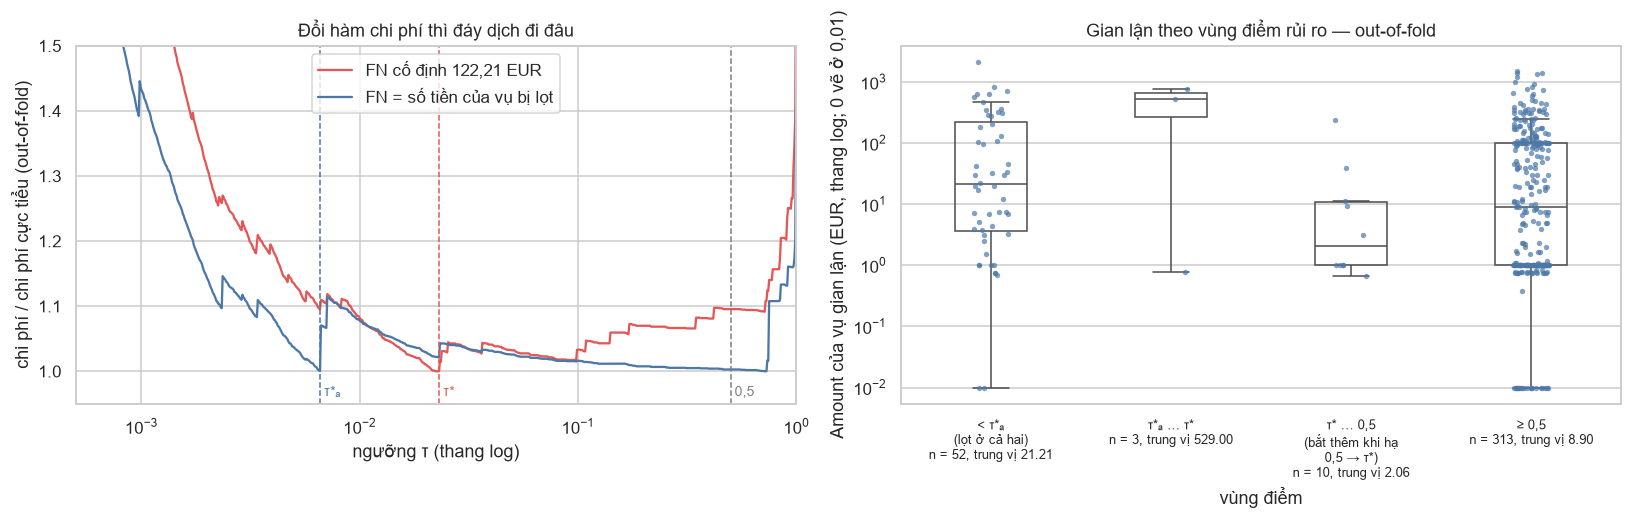

In [13]:
fig, truc = plt.subplots(1, 2, figsize=(15, 4.8))

# Trái: hai đường chi phí trên out-of-fold, chuẩn hoá theo cực tiểu của chính nó để đặt cùng trục
luoi = np.geomspace(5e-4, 0.999, 800)            # đều trên thang log: đủ mịn cả vùng 0,05 … 0,7
dc_co_dinh = cost_curve(y_train, oof, thresholds=luoi, cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP,
                        sample_fraction=PHAN_TRAIN)
dc_theo_tien = cost_curve(y_train, oof, thresholds=luoi, cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN,
                          fn_costs=SO_TIEN_TRAIN)
ax = truc[0]
ax.plot(luoi, dc_co_dinh["expected_cost"] / dc_co_dinh["expected_cost"].min(), label="FN cố định 122,21 EUR",
        color="#E45756")
ax.plot(luoi, dc_theo_tien["expected_cost"] / dc_theo_tien["expected_cost"].min(), label="FN = số tiền của vụ bị lọt",
        color="#4C78A8")
for t, ten, mau in ((NAIVE_THRESHOLD, "0,5", "#7F7F7F"), (TAU_SAO, "τ*", "#E45756"), (TAU_SO_TIEN, "τ*ₐ", "#4C78A8")):
    ax.axvline(t, color=mau, ls="--", lw=1)
    ax.text(t, 0.962, f" {ten}", color=mau, fontsize=9)
ax.set_xscale("log"); ax.set_xlim(5e-4, 1); ax.set_ylim(0.95, 1.5)
ax.set_xlabel("ngưỡng τ (thang log)"); ax.set_ylabel("chi phí / chi phí cực tiểu (out-of-fold)")
ax.set_title("Đổi hàm chi phí thì đáy dịch đi đâu"); ax.legend(loc="upper center")

# Phải: số tiền của các vụ gian lận (out-of-fold) theo vùng điểm
vung = pd.cut(oof[y_train == 1], [0, TAU_SO_TIEN, TAU_SAO, NAIVE_THRESHOLD, 1.0 + 1e-9], right=False,
              labels=["< τ*ₐ\n(lọt ở cả hai)", "τ*ₐ … τ*", "τ* … 0,5\n(bắt thêm khi hạ\n0,5 → τ*)", "≥ 0,5"])
ve = pd.DataFrame({"vùng điểm": vung, "Amount": np.maximum(SO_TIEN_TRAIN[y_train == 1], 0.01)})
sns.stripplot(data=ve, x="vùng điểm", y="Amount", ax=truc[1], size=3.5, alpha=0.7, color="#4C78A8")
sns.boxplot(data=ve, x="vùng điểm", y="Amount", ax=truc[1], showfliers=False, width=0.4,
            boxprops={"facecolor": "none"})
truc[1].set_yscale("log"); truc[1].set_ylabel("Amount của vụ gian lận (EUR, thang log; 0 vẽ ở 0,01)")
truc[1].set_title("Gian lận theo vùng điểm rủi ro — out-of-fold")
truc[1].set_xticks(range(len(vung.categories)))
truc[1].set_xticklabels([f"{ten}\nn = {len(nhom)}, trung vị {nhom['Amount'].median():,.2f}"
                         for ten, (_, nhom) in zip(vung.categories, ve.groupby("vùng điểm", observed=False))],
                        fontsize=8.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_amount_cost.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét 6.1 — τ\* chỉ tối ưu dưới giả định "mọi vụ lọt tốn 122,21 EUR"; tính theo số tiền thì lợi
ích của việc hạ ngưỡng 0,5 → τ\* biến mất.**

*Nguồn của 122,21 (6.1a).* Đó là trung bình `Amount` của gian lận trên dữ liệu **thô** — gồm cả tập kiểm
thử và 1.081 dòng trùng. Sau khi loại trùng là 123,87; chỉ trên tập huấn luyện là 115,94. Dùng con số
nào thì τ\* cũng là **0,023173** — đáy đường chi phí đủ phẳng để sai lệch này không đổi kết luận. Báo cáo
vẫn phải ghi rõ nguồn; làm lại từ đầu thì nên dùng 115,94.

*Chi phí theo số tiền (6.1b, 6.1c).* Mỗi vụ lọt tốn đúng số tiền của nó, mỗi cảnh báo vẫn 5 EUR:

| so sánh (A so với B) | tập | hiệu chi phí — FN cố định 122,21 | hiệu chi phí — FN = số tiền |
|---|---|---|---|
| τ\* so với 0,5 | out-of-fold | −707 [−1.513; −24] | +209 [−320; +539] |
| τ\* so với 0,5 | **kiểm thử** | −197 [−676; +160] | **+160 [+103; +217]** — τ\* đắt hơn ở 100% lần lặp |
| τ\*ₐ = 0,0066 so với 0,5 | kiểm thử | −64 [−603; +333] | −36 [−983; +486] |
| τ\*ₐ so với τ\* | kiểm thử | +133 [−157; +315] | −196 [−1.144; +315] |

Lý do nằm ở hình bên phải: những vụ gian lận mà việc hạ ngưỡng 0,5 → τ\* "bắt thêm" là **vụ nhỏ** — trên
out-of-fold trung vị 2,06 EUR (10 vụ), trên tập kiểm thử là 3 vụ 2,22 / 3,76 / 3,79 EUR. Đổi lấy chúng
là 34 cảnh báo giả × 5 EUR = 170 EUR. Câu "hạ ngưỡng từ 0,5 xuống τ\* tiết kiệm ròng 197 EUR" của mục 3
**chỉ đúng khi mỗi vụ lọt được tính là 122,21 EUR**, trong khi 36% vụ gian lận có số tiền ≤ 1 EUR
(notebook 01).

Chọn theo số tiền thì ngưỡng tối ưu trên out-of-fold là τ\*ₐ = 0,0066, thấp hơn τ\*: dưới τ\* có vài vụ
**lớn** (3 vụ giữa τ\*ₐ và τ\*, trung vị 529 EUR). Nhưng đường chi phí theo số tiền phẳng và lởm chởm
trên cả dải 0,007 … 0,7 (hình trái), và τ\*ₐ không hơn 0,5 hay τ\* một cách có ý nghĩa thống kê — mọi
khoảng tin cậy của nó đều chứa 0. Khác biệt duy nhất có ý nghĩa là chiều **ngược** với mục 3: trên tập
kiểm thử, τ\* đắt hơn 0,5. Tiền mất phần lớn nằm ở vài vụ lớn mà
ngưỡng hợp lý nào cũng bỏ lọt: ở τ\*, 3 vụ lớn nhất (549, 723, 1.097 EUR) chiếm 63% trong 3.783 EUR lọt
của tập kiểm thử, còn 8/18 vụ lọt có số tiền ≤ 1 EUR.

**Hệ quả cho báo cáo và bảo vệ.** Luận điểm vững không phải "τ\* = 0,0232 tiết kiệm tiền", mà là: (1) đáy
chi phí phẳng trên một dải ngưỡng rộng dưới cả hai cách tính; (2) trong dải đó, chọn ngưỡng theo **năng
lực thẩm định** (cảnh báo/ngày) và theo giả định chi phí mà nghiệp vụ xác nhận; (3) giả định chi phí phải
được nêu rõ, vì nó quyết định cả dấu của khoản "tiết kiệm". τ mặc định của hệ thống **không đổi** ở
đây — đó là quyết định nghiệp vụ, không phải kết luận thống kê.

In [14]:
# 6.2 — Ngưỡng "đề xuất chặn": nhỏ nhất mà MỌI ngưỡng từ đó trở lên có precision ≥ p trên out-of-fold.
# So với luật cũ 3τ*. Dải review = [τ*, ngưỡng chặn), dải block = [ngưỡng chặn, 1].
LUAT_CHAN = {"luật cũ: 3τ*": 3 * TAU_SAO}
for p in (0.90, 0.95, 0.97):
    LUAT_CHAN[f"precision ≥ {p:.0%} (OOF)"] = pick_threshold(
        y_train, oof, "min_precision", value=p, thresholds=UNG_VIEN, sample_fraction=PHAN_TRAIN)

bang_chan = []
for ten, t_chan in LUAT_CHAN.items():
    bien = max(TAU_SAO, t_chan)
    for tap, y, s in (("out-of-fold", y_train, oof), ("kiểm thử", y_test, diem_test)):
        review, block = (s >= TAU_SAO) & (s < bien), s >= bien
        bang_chan.append({"luật": ten, "ngưỡng chặn": t_chan, "tập": tap,
                          "review: gian lận": int(y[review].sum()), "review: hợp lệ": int((review & (y == 0)).sum()),
                          "block: gian lận": int(y[block].sum()), "block: hợp lệ": int((block & (y == 0)).sum()),
                          "precision của block": float(y[block].mean()) if block.any() else np.nan})
bang_chan = pd.DataFrame(bang_chan)
bang_chan.to_csv(REPORTS_DIR / "block_threshold.csv", index=False, encoding="utf-8")
display(bang_chan.style.format({"ngưỡng chặn": "{:.4f}", "precision của block": "{:.3f}"}).hide(axis="index"))

luật,ngưỡng chặn,tập,review: gian lận,review: hợp lệ,block: gian lận,block: hợp lệ,precision của block
luật cũ: 3τ*,0.0695,out-of-fold,4,64,319,73,0.814
luật cũ: 3τ*,0.0695,kiểm thử,0,19,77,19,0.802
precision ≥ 90% (OOF),0.5568,out-of-fold,10,103,313,34,0.902
precision ≥ 90% (OOF),0.5568,kiểm thử,3,35,74,3,0.961
precision ≥ 95% (OOF),0.9735,out-of-fold,24,122,299,15,0.952
precision ≥ 95% (OOF),0.9735,kiểm thử,8,37,69,1,0.986
precision ≥ 97% (OOF),0.9908,out-of-fold,29,128,294,9,0.970
precision ≥ 97% (OOF),0.9908,kiểm thử,9,37,68,1,0.986


**Nhận xét 6.2 — ngưỡng đề xuất chặn theo precision thay cho 3τ.**

Luật cũ `block` khi điểm ≥ 3τ\* = 0,0695 không dựa trên phân tích nào và cho kết quả sai hẳn: trên tập
kiểm thử, dải `review` (τ\* … 3τ\*) có 19 giao dịch và **không vụ gian lận nào**, còn dải `block` chặn tự
động 96 giao dịch, trong đó **19 khách hợp lệ** (precision 0,80) — một nửa số cảnh báo giả bị chặn thẳng
thay vì được người thẩm định xem.

Chọn lại: ngưỡng chặn là ngưỡng nhỏ nhất mà **mọi** ngưỡng từ đó trở lên có precision ≥ p trên
out-of-fold (`pick_threshold(..., "min_precision")`; precision không đơn điệu theo ngưỡng nên đòi cả phần
đuôi). Với p = 95% — mức API dùng (`api/config.py → BLOCK_MIN_PRECISION`):

- τ_chặn = **0,9735**. Out-of-fold: chặn 314, precision 0,952 (đúng như đặt). Tập kiểm thử: chặn 70, trong
  đó **69 gian lận, 1 khách hợp lệ** (precision 0,986).
- Dải `review` trên tập kiểm thử: 45 giao dịch, **8 vụ gian lận** — đúng loại việc cần con người.
- p = 90% (τ_chặn 0,557) chặn thêm 2 khách hợp lệ để bớt 7 giao dịch phải xem; p = 97% (0,991) gần như
  trùng 95%.

Cái giá: người thẩm định xem 45 thay vì 19 giao dịch trên tập kiểm thử. Đổi lại, số khách hợp lệ bị chặn
tự động giảm từ 19 xuống 1.

In [15]:
# 6.3 — Điểm rủi ro có dùng như xác suất được không? Bảng độ tin cậy theo dải điểm cố định
# (lượng tử không dùng được: 99% điểm dồn dưới 0,001). Khoảng tin cậy Wilson 95% cho tỷ lệ thật.
BIEN_DIEM = [0, 0.001, 0.005, TAU_SAO, 0.1, 0.5, 0.9, 1.0 + 1e-9]


def wilson(k, n, z=1.96):
    p = k / n
    tam, nua = (p + z * z / (2 * n)) / (1 + z * z / n), z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return tam - nua, tam + nua


dong = []
for tap, y, s in (("out-of-fold", y_train, oof), ("kiểm thử", y_test, diem_test)):
    nhom = pd.cut(s, BIEN_DIEM, right=False)
    for khoang, chi_so in pd.DataFrame({"y": y, "s": s, "nhom": nhom}).groupby("nhom", observed=True):
        n, k = len(chi_so), int(chi_so["y"].sum())
        thap, cao = wilson(k, n)
        dong.append({"tập": tap, "dải điểm": f"[{khoang.left:.4g}; {min(khoang.right, 1):.4g})", "n": n,
                     "gian lận": k, "điểm trung bình": chi_so["s"].mean(), "tỷ lệ gian lận thật": k / n,
                     "KTC thấp": thap, "KTC cao": cao,
                     "điểm TB trong KTC": thap <= chi_so["s"].mean() <= cao})
tin_cay = pd.DataFrame(dong)
tin_cay.to_csv(REPORTS_DIR / "calibration.csv", index=False, encoding="utf-8")
display(tin_cay.style.format({"điểm trung bình": "{:.4f}", "tỷ lệ gian lận thật": "{:.4f}", "KTC thấp": "{:.4f}",
                              "KTC cao": "{:.4f}"}).hide(axis="index"))
for tap, y, s in (("out-of-fold", y_train, oof), ("kiểm thử", y_test, diem_test)):
    print(f"{tap:12s}: Brier {np.mean((s - y) ** 2):.6f} (đoán hằng số tỷ lệ gian lận: "
          f"{np.mean((y.mean() - y) ** 2):.6f}); điểm TB {s.mean():.5f} so với tỷ lệ thật {y.mean():.5f}")

tập,dải điểm,n,gian lận,điểm trung bình,tỷ lệ gian lận thật,KTC thấp,KTC cao,điểm TB trong KTC
out-of-fold,[0; 0.001),225144,42,0.0000,0.0002,0.0001,0.0003,False
out-of-fold,[0.001; 0.005),1075,9,0.0021,0.0084,0.0044,0.0158,False
out-of-fold,[0.005; 0.0232),301,4,0.0103,0.0133,0.0052,0.0337,True
out-of-fold,[0.0232; 0.1),78,5,0.0441,0.0641,0.0277,0.1414,True
out-of-fold,[0.1; 0.5),35,5,0.2143,0.1429,0.0626,0.2938,True
out-of-fold,[0.5; 0.9),20,7,0.7684,0.3500,0.1812,0.5671,False
out-of-fold,[0.9; 1),327,306,0.9968,0.9358,0.9038,0.9576,False
kiểm thử,[0; 0.001),56216,12,0.0000,0.0002,0.0001,0.0004,False
kiểm thử,[0.001; 0.005),333,3,0.0021,0.0090,0.0031,0.0261,False
kiểm thử,[0.005; 0.0232),82,3,0.0095,0.0366,0.0125,0.1021,False


out-of-fold : Brier 0.000408 (đoán hằng số tỷ lệ gian lận: 0.001663); điểm TB 0.00159 so với tỷ lệ thật 0.00167
kiểm thử    : Brier 0.000419 (đoán hằng số tỷ lệ gian lận: 0.001671); điểm TB 0.00147 so với tỷ lệ thật 0.00167


**Nhận xét 6.3 — điểm rủi ro xếp hạng tốt nhưng không phải xác suất ở hai đầu.**

Tính gộp thì điểm khớp tỷ lệ thật: trung bình 0,00159 so với 0,00167 (out-of-fold), Brier 0,000408 so với
0,001663 của cách đoán hằng số — tốt hơn khoảng 4 lần. Nhưng theo từng dải (bảng trên, KTC Wilson 95%):

- **Đầu cao quá tự tin.** Dải ≥ 0,9: điểm trung bình 0,997 nhưng tỷ lệ gian lận thật 0,936 [0,904; 0,958]
  trên out-of-fold. Dải 0,5 … 0,9: điểm 0,77, tỷ lệ thật 0,35 [0,18; 0,57].
- **Đầu thấp quá tự tin theo chiều ngược lại.** Dải < 0,001 (99% giao dịch): điểm trung bình 0,000017
  nhưng tỷ lệ thật 0,00019 — gấp khoảng 10 lần; dải 0,001 … 0,005 thấp hơn thật khoảng 4 lần.
- Trên out-of-fold, các dải giữa (0,005 … 0,5) nằm trong khoảng tin cậy.

Đây là kiểu lệch quen thuộc của mô hình boosting nhiều cây: điểm bị đẩy về hai phía 0 và 1 (quá tự tin). Nó
**không** ảnh hưởng tới mọi kết quả dựa trên thứ hạng và ngưỡng (PR-AUC, τ\*, bảng ngưỡng), vì các kết quả
đó không đọc điểm như xác suất. Nó **có** ảnh hưởng nếu ai đó đọc "điểm 0,99 = chắc 99% là gian lận",
hoặc tính tổn thất kỳ vọng `điểm × số tiền` cho từng giao dịch. Giao diện nên gọi là "điểm rủi ro", không
phải "xác suất". Cần xác suất thật thì hiệu chỉnh đơn điệu (isotonic) trên out-of-fold — không đổi thứ
hạng nên không đổi ngưỡng hay PR-AUC.

### 6.4 Tổng kết mục 6

| Câu hỏi | Kết quả | Đã thay đổi gì |
|---|---|---|
| 122,21 EUR lấy từ đâu | trung bình trên dữ liệu thô; con số chỉ-train 115,94 cho cùng τ\* | không đổi số; ghi rõ nguồn (02 §2, báo cáo) |
| Chi phí theo số tiền | τ\* đắt hơn 0,5 trên tập kiểm thử (+160 [+103; +217] EUR); τ\*ₐ = 0,0066 không hơn 0,5 hay τ\* một cách có ý nghĩa | thêm `fn_costs` vào `src/threshold.py`; τ mặc định **giữ nguyên** — quyết định nghiệp vụ |
| Ngưỡng đề xuất chặn | precision ≥ 95% trên OOF → 0,9735; tập kiểm thử chặn 69 gian lận + 1 hợp lệ (luật 3τ: 77 + 19) | API đổi luật `block` (05 §2) |
| Điểm có phải xác suất | xếp hạng tốt, Brier tốt hơn 4 lần; lệch ở hai đầu | ghi chú cho giao diện và báo cáo |

Bảng: `reports/amount_cost_comparison.csv`, `reports/amount_cost_bootstrap.csv`,
`reports/block_threshold.csv`, `reports/calibration.csv`. Hình: `reports/figures/06_amount_cost.png`.